# ChampionCHIP eXperience — Fase 2 — RV32I_Zmmul_Xicrc
## Notebook de execução ponta a ponta

Este notebook reproduz, de ponta a ponta e com saídas reais, o pipeline de
engenharia do processador **RV32I_Zmmul_Xicrc** submetido à Fase 2 da
ChampionCHIP eXperience: arquitetura → RTL → verificação (unitária e por
instrução) → firmware → (quando disponível) fluxo físico OpenLane/SKY130.

Todo o ambiente de simulação (Icarus Verilog, Verilator, GCC RISC-V,
GTKWave) roda em um container Docker (`championchip-dev`, ver
`tools/docker/Dockerfile`), e este notebook apenas invoca os mesmos scripts
versionados em `scripts/` — não há lógica duplicada aqui.

**Documentos de referência:**
- [`Plano_Mestre_ChampionCHIP_Fase2.pdf`](../Plano_Mestre_ChampionCHIP_Fase2.pdf) — plano de engenharia completo (19 p.)
- [`Champion-chip-guia-fase-2.pdf`](../Champion-chip-guia-fase-2.pdf) — guia oficial da competição
- [`README.md`](../README.md) — visão geral e estrutura do repositório
- [`SPEC_GAPS.md`](../SPEC_GAPS.md) — lacunas do guia oficial e decisões
- [`DECISIONS.md`](../DECISIONS.md) — ADRs, incluindo 2 bugs reais encontrados e corrigidos pela verificação
- [`TEST_MATRIX.csv`](../TEST_MATRIX.csv) — 47 instruções × status × evidência

> **Pré-requisitos para re-executar:** Docker Desktop rodando, imagem
> `championchip-dev:latest` construída (`make build-image` na raiz do
> projeto), e a unidade `G:` acessível (o projeto vive numa pasta
> sincronizada pelo Google Drive Desktop).


In [1]:
import subprocess, os, json, textwrap
from pathlib import Path

PROJDIR = Path(r"G:\Outros computadores\Meu computador\Controle Base\Projetos, Robos e Automação\Projetos Git\Projetos Extras (Portfolio)\ChampionCHIP (Terminar)")
BASH = r"C:\Program Files\Git\bin\bash.exe"

def run(cmd, timeout=600):
    """Executa um comando via Git Bash na raiz do projeto e imprime a saida em tempo real."""
    full = f'cd "{PROJDIR.as_posix().replace("C:", "/c").replace(":", "")}" 2>/dev/null; cd "{PROJDIR}" && {cmd}'
    # Git Bash aceita paths Windows diretamente em muitos casos; usamos -lc com o path como esta.
    proc = subprocess.run([BASH, "-lc", f'cd "{PROJDIR}" && {cmd}'],
                           capture_output=True, text=True, timeout=timeout)
    print(proc.stdout)
    if proc.returncode != 0:
        print("STDERR:\n", proc.stderr)
    print(f"[exit code: {proc.returncode}]")
    return proc

print("Projeto:", PROJDIR)
print("Existe?", PROJDIR.exists())


Projeto: G:\Outros computadores\Meu computador\Controle Base\Projetos, Robos e Automação\Projetos Git\Projetos Extras (Portfolio)\ChampionCHIP (Terminar)
Existe? True


## 1. Estrutura do repositório

In [2]:
r = run(r"find . -maxdepth 2 -not -path './.git*' -not -path './docs/evidence*' | sort")

.
./Champion-chip-guia-fase-2.pdf
./CHANGELOG.md
./DECISIONS.md
./docs
./docs/architecture
./docs/ChampionCHIP_EndToEnd.ipynb
./docs/submission
./firmware
./firmware/build
./firmware/linker
./firmware/official
./firmware/smoke
./KNOWN_ISSUES.md
./Makefile
./openlane
./openlane/config
./openlane/constraints
./openlane/runs
./openlane/scripts
./Plano_Mestre_ChampionCHIP_Fase2.docx
./Plano_Mestre_ChampionCHIP_Fase2.pdf
./rascunho.d
./README.md
./reports
./rtl
./rtl/core
./rtl/memory
./rtl/top
./scripts
./scripts/build_firmware.sh
./scripts/run_firmware_sim.sh
./scripts/run_lint.sh
./scripts/run_openlane.sh
./scripts/run_regression.sh
./scripts/sync_mirror.sh
./SPEC_GAPS.md
./STATUS.md
./tb
./tb/common
./tb/firmware
./tb/isa
./tb/unit
./TEST_MATRIX.csv
./tools
./tools/docker

[exit code: 0]


## 2. Arquitetura (resumo)

- **Núcleo multicycle** (não pipelined), FSM de 16 estados (`rtl/core/control_unit.sv`).
- **Datapath**: regfile 32×32, ALU compartilhada (11 operações), gerador de
  imediatos I/S/B/U/J, comparador de branch (6 condições), multiplicador
  Zmmul (MUL/MULH/MULHSU/MULHU via produto de 64 bits), unidade CRC Xicrc
  (estrutural, parametrizada, bloqueada — ver `SPEC_GAPS.md` SG-01), LSU
  (load/store com sign/zero-extend e byte-write mask).
- **Memória**: `address_decoder` roteia IMEM (0x0040_0000, ROM) / DMEM
  (0x1001_0000, SRAM síncrona) — DMEM síncrona exige o estado `MEM_WAIT`
  explícito na FSM (o guia oficial afirma que a DMEM só conclui a operação
  após um clock).
- **Registradores de estágio "free-running"** (ALUOut/MultOut/CrcOut/link),
  estilo clássico Patterson&Hennessy — ver `DECISIONS.md` ADR-002.

Dois bugs reais de PC foram encontrados pela verificação dirigida e
corrigidos (`DECISIONS.md` ADR-003) — exatamente o tipo de risco (R-07)
que o Plano Mestre havia antecipado.


In [3]:
r = run(r"docker images championchip-dev:latest --format '{{.Repository}}:{{.Tag}}  criada há {{.CreatedSince}}  {{.Size}}'")

championchip-dev:latest  criada hÃ¡ About an hour ago  3.37GB

[exit code: 0]


## 3. Regressão RTL — testes unitários + testes de ISA (dirigidos por instrução)

In [4]:
r = run("bash scripts/run_regression.sh", timeout=300)

Sincronizado: projeto -> /c/tmp/championchip-build
==== UNIT TESTS ====
PASS  tb_alu
PASS  tb_regfile
PASS  tb_imm_gen
PASS  tb_branch_cmp
PASS  tb_mult_unit
PASS  tb_lsu
PASS  tb_address_decoder
PASS  tb_crc_unit
==== ISA TESTS ====
PASS  tb_isa_alu
PASS  tb_isa_mem_upper_sys
PASS  tb_isa_branch_jump
PASS  tb_isa_zmmul
REGRESSION EXIT CODE: 0

[exit code: 0]


### Leitura dos resultados

- **8 testbenches unitários** (`tb/unit/`): ALU, regfile, imm_gen,
  branch_cmp, mult_unit, lsu, address_decoder, crc_unit (estrutural).
- **4 testbenches de ISA** (`tb/isa/`): cobrem as 44 instruções fechadas
  (RV32I 40/40 + Zmmul 4/4) com scoreboard direto no regfile do DUT.

Xicrc (3 instruções) fica de fora da regressão funcional por decisão de
projeto — ver `SPEC_GAPS.md` SG-01.


## 4. Matriz de cobertura da ISA (47 instruções)

In [5]:
import pandas as pd
df = pd.read_csv(PROJDIR / "TEST_MATRIX.csv")
df

,num,categoria,instrucao,testbench,status,evidencia
0,1,ALU reg,ADD,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
1,2,ALU reg,SUB,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
2,3,ALU reg,SLL,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
3,4,ALU reg,SLT,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
4,5,ALU reg,SLTU,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
5,6,ALU reg,XOR,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
6,7,ALU reg,SRL,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
7,8,ALU reg,SRA,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
8,9,ALU reg,OR,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log
9,10,ALU reg,AND,tb_isa_alu.sv,PASS,docs/evidence/logs/regression_latest.log


In [6]:
resumo = df["status"].apply(lambda s: "PASS" if str(s).startswith("PASS") else ("BLOCKED" if "BLOCKED" in str(s) else str(s)))
resumo.value_counts()

status
PASS       44
BLOCKED     3
Name: count, dtype: int64

## 5. Lint sintetizável (Verilator) sobre o top físico

In [7]:
r = run("bash scripts/run_lint.sh", timeout=180)

Sincronizado: projeto -> /c/tmp/championchip-build
%Warning-UNUSEDSIGNAL: rtl/top/chip_top.sv:31:26: Signal is not used: 'uart_rx_i'
                                                : ... note: In instance 'chip_top'
   31 |     input  logic         uart_rx_i
      |                          ^~~~~~~~~
                       ... For warning description see https://verilator.org/warn/UNUSEDSIGNAL?v=5.020
                       ... Use "/* verilator lint_off UNUSEDSIGNAL */" and lint_on around source to disable this message.
%Warning-UNUSEDSIGNAL: rtl/top/chip_top.sv:34:18: Signal is not used: 'pc_dbg'
                                                : ... note: In instance 'chip_top'
   34 |     logic [31:0] pc_dbg, halt_dbg_bit;
      |                  ^~~~~~
%Warning-UNUSEDSIGNAL: rtl/top/chip_top.sv:34:26: Signal is not driven, nor used: 'halt_dbg_bit'
                                                : ... note: In instance 'chip_top'
   34 |     logic [31:0] pc_dbg, halt_dbg_bit;
     

## 6. Firmware de smoke-test — cadeia toolchain → ELF → hex → simulação → execução

Firmware oficial da competição **não está disponível** neste repositório
(`SPEC_GAPS.md` SG-05). Para ainda assim comprovar a cadeia completa de
ferramentas com evidência real (não apenas testes hand-encoded), foi escrito
um firmware autoral em estilo `riscv-tests` (`firmware/smoke/smoke_test.S`),
compilado com o GCC RISC-V real (`riscv64-unknown-elf-gcc -march=rv32im`),
linkado com o mapa de memória do core e simulado sobre `soc_top`.


In [8]:
r = run("bash scripts/run_firmware_sim.sh", timeout=180)

Sincronizado: projeto -> /c/tmp/championchip-build
   text	   data	    bss	    dec	    hex	filename
    400	     40	      0	    440	    1b8	smoke_test.elf
palavras geradas: 100
OK: firmware/build/smoke_test.hex gerado
result_addr=0x10010020 -> RESULT_WORD_OFFSET=8
[INFO] result_sig=600dc0de testnum=9 pc_final=0040018c
[ pass ] firmware smoke-test PASS (9 blocos)
=== tb_firmware_smoke: PASS ===
tb/firmware/tb_firmware_smoke.sv:60: $finish called at 3510 (1s)
Evidencias salvas em docs/evidence/logs/firmware_smoke.log e firmware/build/

[exit code: 0]


In [9]:
dis_path = PROJDIR / "firmware" / "build" / "smoke_test.dis"
if dis_path.exists():
    print(dis_path.read_text(encoding="utf-8", errors="replace")[:3000])
else:
    print("Disassembly nao encontrado - rode a celula anterior primeiro.")


smoke_test.elf:     file format elf32-littleriscv


Disassembly of section .text:

00400000 <_start>:
  400000:	10012137          	lui	sp,0x10012
  400004:	ff010113          	addi	sp,sp,-16 # 10011ff0 <result_addr+0x1fd0>
  400008:	00000413          	li	s0,0

0040000c <test1_add_sub>:
  40000c:	00140413          	addi	s0,s0,1
  400010:	00c00293          	li	t0,12
  400014:	00500313          	li	t1,5
  400018:	006283b3          	add	t2,t0,t1
  40001c:	01100e13          	li	t3,17
  400020:	13c39c63          	bne	t2,t3,400158 <fail>
  400024:	406283b3          	sub	t2,t0,t1
  400028:	00700e13          	li	t3,7
  40002c:	13c39663          	bne	t2,t3,400158 <fail>

00400030 <test2_logic>:
  400030:	00140413          	addi	s0,s0,1
  400034:	0f000293          	li	t0,240
  400038:	00f00313          	li	t1,15
  40003c:	0062e3b3          	or	t2,t0,t1
  400040:	0ff00e13          	li	t3,255
  400044:	11c39a63          	bne	t2,t3,400158 <fail>
  400048:	0062f3b3          	and	t2,t0,t1
  40004c:	10

## 7. Fluxo físico — OpenLane / SKY130 (RTL-to-GDSII)

**Alvo:** `rv32_core` (o núcleo puro, sem IMEM/DMEM comportamentais — ver
`DECISIONS.md` ADR-008: sintetizar um modelo de memória de até 4 MB em
flip-flops não é realista; a estratégia de memória física fica subordinada
ao macro/template oficial da organização, ainda não disponibilizado —
SPEC_GAPS.md SG-02).

Configuração: `openlane/config/config.json` (clock 40 ns / 25 MHz nesta
rodada baseline, `sky130_fd_sc_hd`, utilização de core 35%). Executado via
OpenLane 2 `--dockerized` dentro do container `championchip-dev`, com o
`docker.sock` do host montado (Docker-in-Docker) — ver `DECISIONS.md`
ADR-009/010/011 para o troubleshooting completo de ambiente até chegar
numa rodada limpa.

**Resultado: fluxo completo, sem erros de DRC/LVS, timing fechado em
todos os corners.**


In [10]:
import json
metrics_path = PROJDIR / "docs" / "evidence" / "openlane" / "run_best" / "metrics.json"
if metrics_path.exists():
    m = json.loads(metrics_path.read_text())
    resumo = {
        "DRC (KLayout)":        m.get("klayout__drc_error__count"),
        "DRC (Magic)":          m.get("magic__drc_error__count"),
        "LVS (device diff)":    m.get("design__lvs_device_difference__count"),
        "LVS (net diff)":       m.get("design__lvs_net_difference__count"),
        "Antenna violations":   m.get("route__antenna_violation__count"),
        "Route DRC (final)":    m.get("route__drc_errors"),
        "Area do core (um2)":   m.get("design__core__area"),
        "Area do die (um2)":    m.get("design__die__area"),
        "Wirelength total":     m.get("route__wirelength"),
        "Setup WNS (nom_tt)":   m.get("timing__setup__wns__corner:nom_tt_025C_1v80"),
        "Setup TNS (nom_tt)":   m.get("timing__setup__tns__corner:nom_tt_025C_1v80"),
        "Hold WNS (nom_tt)":    m.get("timing__hold__wns__corner:nom_tt_025C_1v80"),
        "Max slew violations (nom_tt)": m.get("design__max_slew_violation__count__corner:nom_tt_025C_1v80"),
        "Max cap violations (nom_tt)":  m.get("design__max_cap_violation__count__corner:nom_tt_025C_1v80"),
    }
    for k, v in resumo.items():
        print(f"{k:32s}: {v}")
else:
    print("metrics.json ainda nao disponivel - rode: bash scripts/run_openlane.sh")

DRC (KLayout)                   : 0
DRC (Magic)                     : 0
LVS (device diff)               : 0
LVS (net diff)                  : 0
Antenna violations              : 2
Route DRC (final)               : 0
Area do core (um2)              : 653656
Area do die (um2)               : 681917
Wirelength total                : 999105
Setup WNS (nom_tt)              : 0
Setup TNS (nom_tt)              : 0
Hold WNS (nom_tt)               : 0
Max slew violations (nom_tt)    : 0
Max cap violations (nom_tt)     : 0


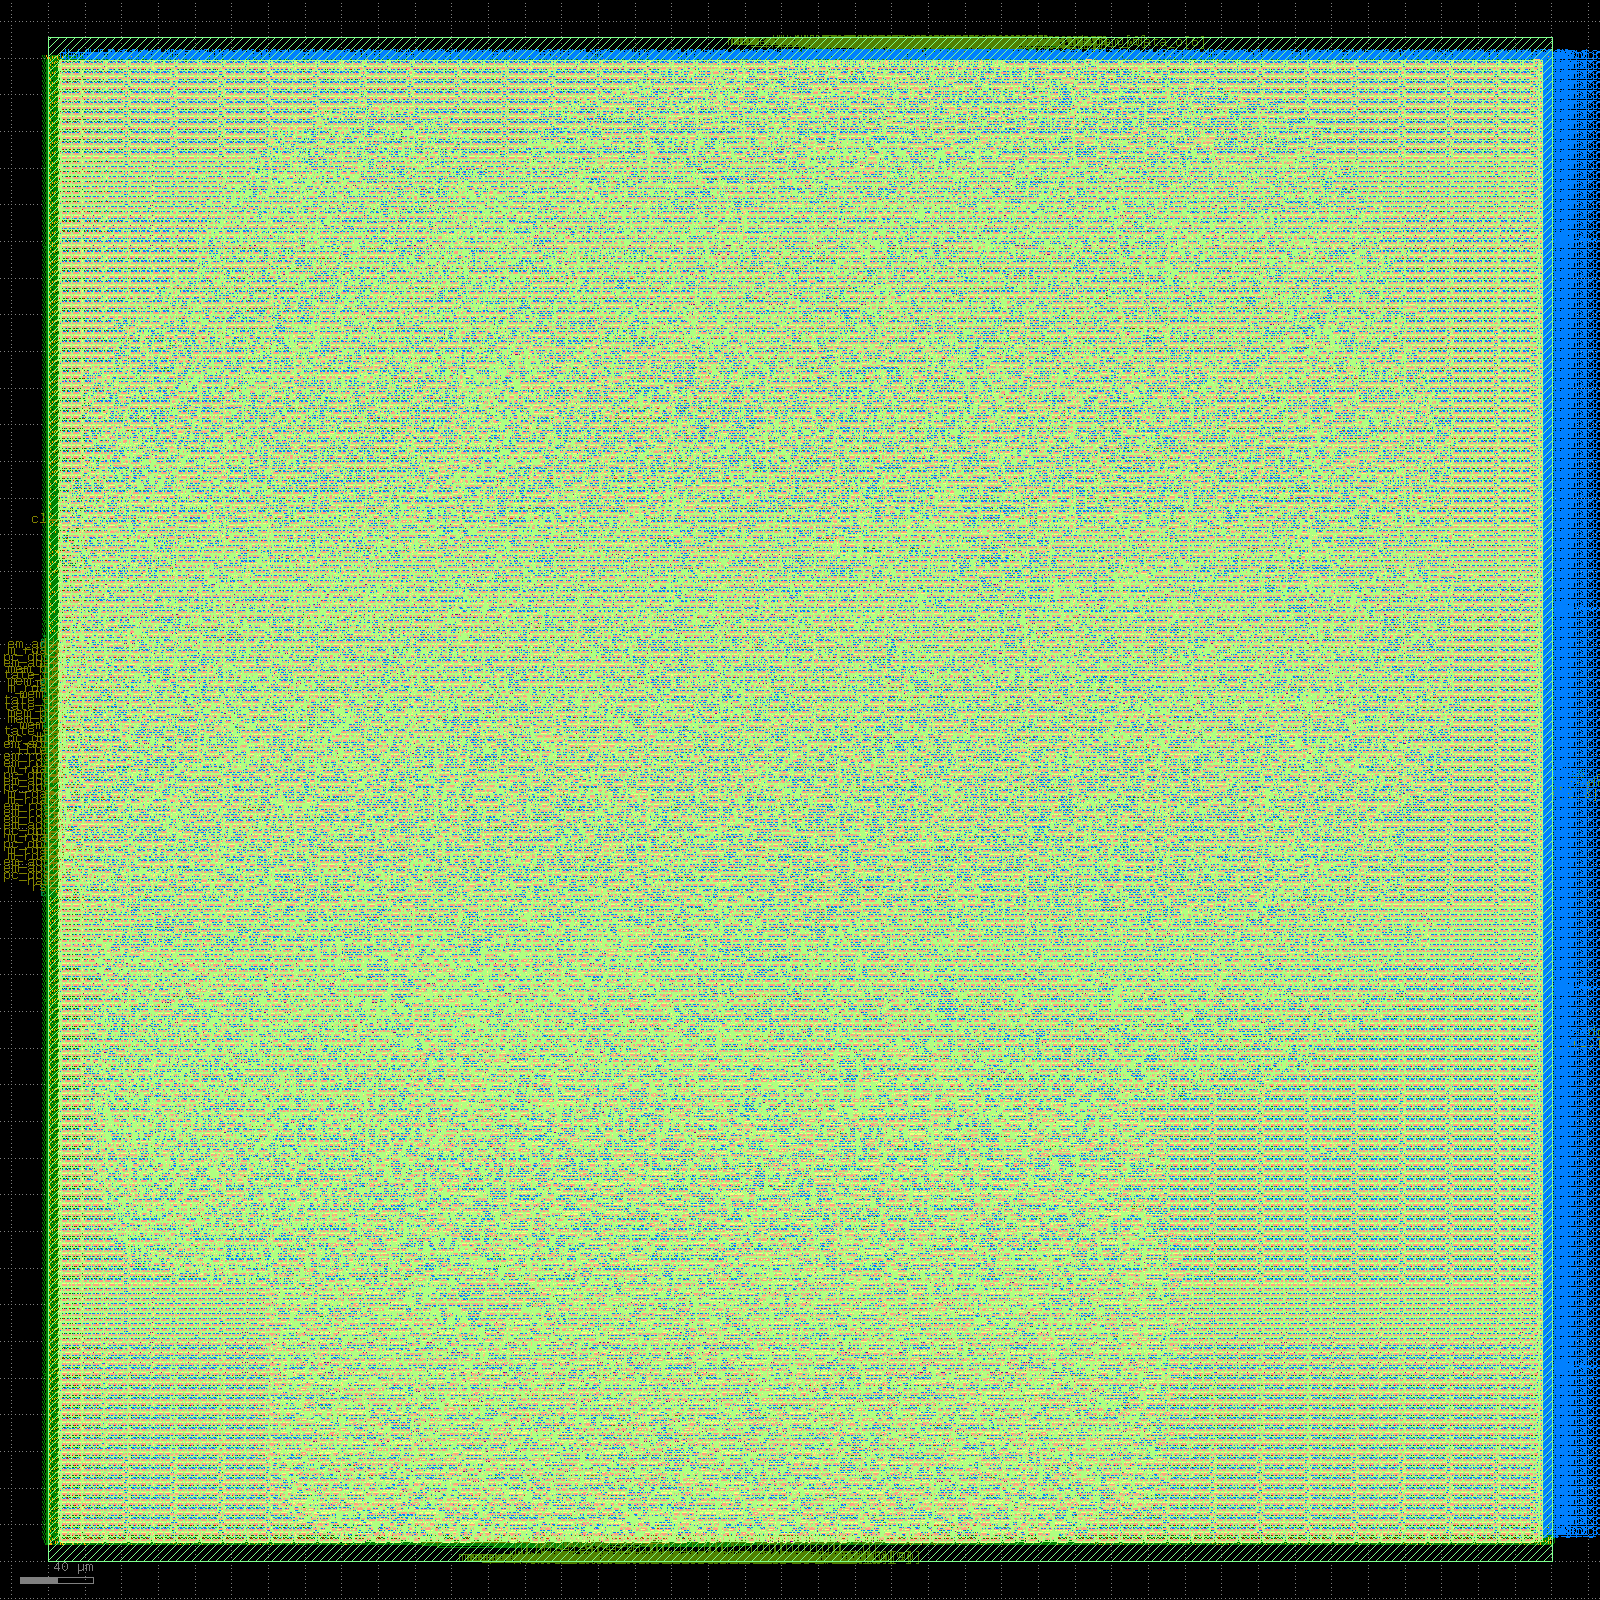

Layout fisico real do rv32_core (die ~820x831 um), renderizado via KLayout a partir do GDSII gerado.


In [11]:
from IPython.display import Image, display
layout_png = PROJDIR / "docs" / "evidence" / "openlane" / "run_best" / "rv32_core_layout.png"
if layout_png.exists():
    display(Image(filename=str(layout_png), width=700))
    print("Layout fisico real do rv32_core (die ~820x831 um), renderizado via KLayout a partir do GDSII gerado.")
else:
    print("Imagem do layout ainda nao gerada.")

## 8. Conclusão e próximos passos

**Status consolidado (ver `CHANGELOG.md` para o histórico completo):**

| Fase | Status |
|------|--------|
| F0 Freeze de especificação | ✅ |
| F1 Skeleton + automação | ✅ |
| F2 Módulos unitários | ✅ 8/8 PASS |
| F3 FSM + core integrado | ✅ |
| F4 RV32I 40/40 | ✅ |
| F5 Zmmul 4/4 + Xicrc 3/3 | ✅ Zmmul / 🔴 Xicrc BLOCKED |
| F6 Firmware | 🟡 smoke-test autoral PASS (9/9); oficial indisponível |
| F7 OpenLane baseline | ✅ DRC 0, LVS 0, timing fechado (10 corners), GDSII gerado |
| F8 Otimização física | ⏳ (corner lento com slew/cap a otimizar) |
| F9 Gate-level regression | ⏳ |
| F10 Relatório/vídeo/submissão | ⏳ |

**Gaps abertos (não inventados, documentados em `SPEC_GAPS.md`):**
SG-01 (semântica Xicrc), SG-02 (macro de memória física oficial), SG-03
(pinout GPIO/serial), SG-04 (polaridade do reset), SG-05 (firmware oficial).

Assim que o material oficial da competição (repositório/template,
especificação Xicrc, firmware de referência) estiver disponível, os passos
seguintes já estão desenhados no Plano Mestre (seção 9) e este notebook
pode ser reexecutado de ponta a ponta para validar o fechamento 47/47.
